# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

Para nossa atividade usaremos uma base de churn também, porém essa base não diz respeito a serviços bancários e sim serviços de internet, telefone e tv - Telecomunicação.

Vamos realizar aqui as etapas de limpeza e tratamento de dados vistos durante a aula, porém aplicados a essa base nova.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';')

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


Legenda dos dados:

*   **CustomerID** : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

*   **Genero** : O genero dos nossos clientes.

*   **Idoso** : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

*   **Casado** : Se nosso cliente é casado ou não.

*   **Dependents** : Se cliente tem dependentes.

*   **Tempo_como_Cliente** : Tempo em meses que nosso cliente está com a nossa empresa.

*   **PhoneService** : Se ele contratou serviço telefônico com a nossa empresa.

*   **Servico_Internet** : Qual o tipo de serviço de internet contratado.

*   **Servico_Seguranca** : Se ele contratou serviço de segurança com a nossa empresa.

*   **Suporte_Tecnico** : Se já acionou o suporte técnico.

*   **StreamingTV** : Se ele contratou serviço de streaming para TV.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **PaymentMethod** : Forma de Pagamento.

*   **Pagamento_Mensal** : Quanto o cliente pagava mensalmente.

*   **Total_Pago** : Total já pago pelo cliente para nossa companhia.

*   **Churn** : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.




# 1 - Carregue a base, verifique se os tipos de dados estão de acordo com cada coluna e caso não estejam realize a transformação dos tipos de dados.

In [28]:
df.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,InternetService,OnlineSecurity,TechSupport,StreamingTV,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),71.45,1840.75,No
16,Female,0,No,No,52,Yes,No internet service,No internet service,No internet service,No internet service,One year,Mailed check,71.45,1022.95,No


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2488 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           2488 non-null   object 
 1   SeniorCitizen    2488 non-null   int64  
 2   Partner          2488 non-null   object 
 3   Dependents       2488 non-null   object 
 4   Tenure           2488 non-null   int64  
 5   PhoneService     2488 non-null   object 
 6   InternetService  2488 non-null   object 
 7   OnlineSecurity   2488 non-null   object 
 8   TechSupport      2488 non-null   object 
 9   StreamingTV      2488 non-null   object 
 10  Contract         2488 non-null   object 
 11  PaymentMethod    2488 non-null   object 
 12  MonthlyCharges   2488 non-null   float64
 13  TotalCharges     2488 non-null   float64
 14  Churn            2488 non-null   object 
dtypes: float64(2), int64(2), object(11)
memory usage: 311.0+ KB


In [30]:
df.isnull().sum()

Gender             0
SeniorCitizen      0
Partner            0
Dependents         0
Tenure             0
PhoneService       0
InternetService    0
OnlineSecurity     0
TechSupport        0
StreamingTV        0
Contract           0
PaymentMethod      0
MonthlyCharges     0
TotalCharges       0
Churn              0
dtype: int64

In [31]:
(df.isnull().sum()/len(df)) * 100

Gender             0.0
SeniorCitizen      0.0
Partner            0.0
Dependents         0.0
Tenure             0.0
PhoneService       0.0
InternetService    0.0
OnlineSecurity     0.0
TechSupport        0.0
StreamingTV        0.0
Contract           0.0
PaymentMethod      0.0
MonthlyCharges     0.0
TotalCharges       0.0
Churn              0.0
dtype: float64

In [32]:
df.dropna(subset=['Gender'], inplace=True)
df['Gender'].isnull().sum()

np.int64(0)

In [33]:
df.dropna(subset=['Churn'], inplace=True)
df['Churn'].isnull().sum()

np.int64(0)

In [34]:
df['PhoneService'] = df['PhoneService'].fillna('Unknown')

In [35]:
df['MonthlyCharges'].mean()

np.float64(66.34256430868167)

In [36]:
df['MonthlyCharges'].median()

71.45

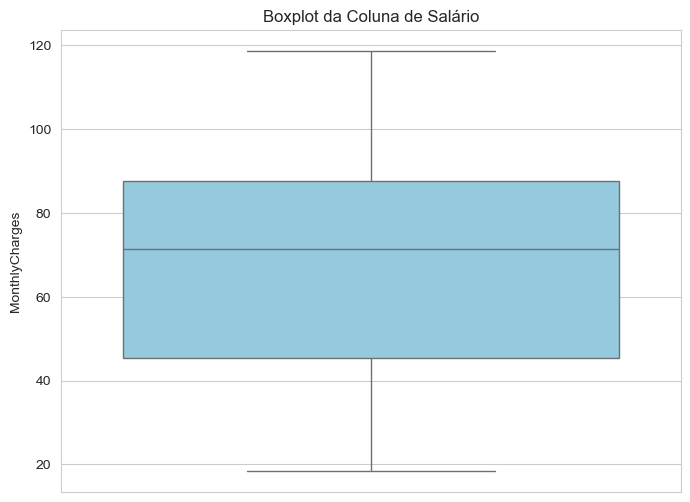

In [37]:
sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='MonthlyCharges', color='skyblue')
plt.title('Boxplot da Coluna de Salário')
plt.ylabel('MonthlyCharges')
plt.show()

In [38]:
df['MonthlyCharges'] = df['MonthlyCharges'].fillna(df['MonthlyCharges'].median())

In [39]:
gender_list = {
    'F': 'Female',
    'f': 'Female',
    'M': 'Male'
}
df['Gender'] = df['Gender'].replace(gender_list)

In [40]:
internet_service_list = {
    'dsl': 'DSL',
    'No': 'No internet service'
}
df['InternetService'] = df['InternetService'].replace(internet_service_list)

In [41]:
df.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,InternetService,OnlineSecurity,TechSupport,StreamingTV,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),71.45,1840.75,No
16,Female,0,No,No,52,Yes,No internet service,No internet service,No internet service,No internet service,One year,Mailed check,71.45,1022.95,No


# 2 - Esse exercício faremos por etapas:
A) Verifique se temos colunas com dados faltantes e traga a % dos dados faltantes por coluna.

In [4]:
(df.isnull().sum()/len(df)) * 100

customerID             0.00
Genero                 0.48
Idoso                  0.00
Casado                 0.00
Dependents             0.00
Tempo_como_Cliente     0.00
PhoneService          59.28
Servico_Internet       0.00
Servico_Seguranca      0.00
Suporte_Tecnico        0.00
StreamingTV            0.00
Tipo_Contrato          0.00
PaymentMethod          0.00
Pagamento_Mensal      13.00
Total_Pago             0.00
Churn                  0.20
dtype: float64

In [ ]:
'''
Genero: 0,48%
PhoneService: 59.28%
Pagamento_Mensal: 13.00%
Churn: 0.20%
'''

B) Exclua nessa etapa as linhas das colunas com dados faltantes que você analisar que esse método é o ideal. Justifique o motivo de estar excluindo essas linhas.

In [ ]:
'''
Excluí os dados faltantes de Genero e Churn,
pois eram uma parcela ínfima de dados e que avaliei
que poderiam ser excluídos.
'''

C) Nessa etapa substitua pela média, mediana ou moda as linhas das colunas com valores faltantes que você analisou e entendeu que esse era o melhor método. Não se esqueça de justificar sua escolha.

In [ ]:
'''
Ao utilizar a mediana em uma distribuição negativamente enviesada 
(onde a média é menor que a mediana), eu evitei que os valores nulos sejam preenchidos 
por um número artificialmente baixo.
A média de $65,6$ está sendo afetada pelos valores extremos inferiores. Preenchendo 
os 12,6% de dados faltantes com a média, estará subestimando o valor real que a maioria 
dos clientes paga, inserindo um viés artificial de "baixo custo" no dataset.
'''

**Dica variáveis numéricas:** Não se esqueça de verificar a distrbuição dos dados, média e mediana.

**Dica variáveis categóricas:** Caso precise substituir uma variável categórica utilize um gráfico de barras para verificar a que mais aparece e utilizar ela na substituição.
Ou você pode optar por excluir a coluna, mas justifique sua escolha.

Caso opte por substituir você pode utilizar a função fillna:
df['SUACOLUNA'].fillna("VALOR QUE SUBSTITUIRA O NULO", inplace=True)
Ela funcionará como a replace.

In [ ]:
# Descrito na etapa 1

# 3 - Verifique se encontramos valores digitados incorretamente, ou com letras maiusculas ou minusculas, ou até mesmo mesmos valores porém escritos de forma dirente e corrija.

In [ ]:
# Descrito na etapa 1

# [EXTRA] 4 - Caso deseje, para manter um padrão na sua base, renomeie as colunas ou deixando em português, ou inglês.

In [ ]:
# Descrito na etapa 1